In [1]:
!nvidia-smi
!pip install -q transformers==4.46.3 accelerate
!pip install -q albumentations Pillow opencv-python-headless gdown

Wed May 13 18:30:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE_DIR = '/content/drive/MyDrive/wscan_training'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f"Drive ready → {DRIVE_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive ready → /content/drive/MyDrive/wscan_training


In [3]:
import os, shutil

FUSEG_URL = "https://github.com/uwm-bigdata/wound-segmentation/archive/refs/heads/master.zip"

# Clean any previous extraction to avoid "replace?" prompts
if os.path.exists('/content/wound-segmentation-master'):
    shutil.rmtree('/content/wound-segmentation-master')

print("Downloading uwm-bigdata/wound-segmentation ...")
!wget -q --show-progress -O /content/fuseg.zip "{FUSEG_URL}"

# -o = overwrite silently, -q = quiet, no prompts
!unzip -o -q /content/fuseg.zip -d /content/
!ls /content/wound-segmentation-master/
print("\n✔ Dataset extracted")

/content/fuseg.zip      [            <=>     ] 336.81M  18.3MB/s    in 19s     
_config.yml			  figures     predict.py	train.py
data				  index.html  README.md		utils
evaluate_with_post_processing.py  models      training_history

✔ Dataset extracted


In [5]:
import os, glob, shutil, random
import numpy as np
from PIL import Image

# Set BASE explicitly (in case kernel restarted)
BASE = '/content/wound-segmentation-master'
DATA = '/content/wound_data'
VAL_RATIO = 0.15

for split in ['train', 'val']:
    os.makedirs(f'{DATA}/images/{split}', exist_ok=True)
    os.makedirs(f'{DATA}/masks/{split}',  exist_ok=True)

def remap_mask(arr: np.ndarray) -> np.ndarray:
    if int(arr.max()) <= 3:
        return arr.astype(np.uint8)
    out = np.zeros_like(arr, dtype=np.uint8)
    for src, dst in [(0,0),(85,1),(170,2),(255,3)]:
        out[arr == src] = dst
    return out

# Dataset has images in /images/ and masks in /labels/ — all PNG
img_pngs  = sorted(glob.glob(f"{BASE}/**/images/*.png", recursive=True))
mask_pngs = sorted(glob.glob(f"{BASE}/**/labels/*.png", recursive=True))

print(f"Image PNGs : {len(img_pngs)}")
print(f"Mask  PNGs : {len(mask_pngs)}")

# Match by filename stem
mask_by_stem = {os.path.splitext(os.path.basename(m))[0]: m for m in mask_pngs}
pairs = []
for img_path in img_pngs:
    stem = os.path.splitext(os.path.basename(img_path))[0]
    if stem in mask_by_stem:
        pairs.append((img_path, mask_by_stem[stem]))
    
print(f"Matched pairs: {len(pairs)}")
print(f"Sample: {pairs[0][0]} ↔ {pairs[0][1]}")

assert len(pairs) > 0, "No pairs found!"

random.shuffle(pairs)
n_val = max(1, int(len(pairs) * VAL_RATIO))
split_data = {'val': pairs[:n_val], 'train': pairs[n_val:]}

for split, split_pairs in split_data.items():
    for i, (img_path, msk_path) in enumerate(split_pairs):
        stem = f"{split}_{i:04d}"
        Image.open(img_path).convert("RGB").save(
            f"{DATA}/images/{split}/{stem}.jpg", quality=95)
        mask = remap_mask(np.array(Image.open(msk_path).convert("L")))
        Image.fromarray(mask).save(f"{DATA}/masks/{split}/{stem}.png")
    print(f"  {split}: {len(split_pairs)} pairs")

print(f"\n✔ Dataset ready at {DATA}")


Image PNGs : 1370
Mask  PNGs : 1170
Matched pairs: 1170
Sample: /content/wound-segmentation-master/data/Foot Ulcer Segmentation Challenge/train/images/0011.png ↔ /content/wound-segmentation-master/data/Foot Ulcer Segmentation Challenge/train/labels/0011.png
  val: 175 pairs
  train: 995 pairs

✔ Dataset ready at /content/wound_data


In [9]:
!pip install -q albumentations==1.3.1
import importlib, albumentations
importlib.reload(albumentations)
print(albumentations.__version__)  # should print 1.3.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 11.1 MB/s eta 0:00:00
1.3.1


In [13]:
import os, random
import numpy as np
from PIL import Image
from torch.utils.data import Dataset
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import torchvision.transforms as T

DATA          = '/content/wound_data'
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def train_transform(image, mask):
    # Random resized crop (paired)
    i, j, h, w = T.RandomResizedCrop.get_params(image, scale=(0.6, 1.0), ratio=(0.75, 1.33))
    image = TF.resized_crop(image, i, j, h, w, size=[512, 512])
    mask  = TF.resized_crop(mask,  i, j, h, w, size=[512, 512],
                            interpolation=TF.InterpolationMode.NEAREST)
    # Horizontal flip
    if random.random() > 0.5:
        image, mask = TF.hflip(image), TF.hflip(mask)
    # Vertical flip
    if random.random() > 0.3:
        image, mask = TF.vflip(image), TF.vflip(mask)
    # 90° rotation
    if random.random() > 0.4:
        k = random.choice([90, 180, 270])
        image = TF.rotate(image, k)
        mask  = TF.rotate(mask,  k)
    # Colour jitter (image only)
    image = TF.adjust_brightness(image, 1 + random.uniform(-0.3, 0.3))
    image = TF.adjust_contrast(image,   1 + random.uniform(-0.3, 0.3))
    image = TF.adjust_saturation(image, 1 + random.uniform(-0.3, 0.3))
    # To tensor + normalise
    pv  = TF.normalize(TF.to_tensor(image), IMAGENET_MEAN, IMAGENET_STD)
    lbl = torch.from_numpy(np.array(mask)).long()
    return pv, lbl


def val_transform(image, mask):
    image = TF.resize(image, [512, 512])
    mask  = TF.resize(mask,  [512, 512], interpolation=TF.InterpolationMode.NEAREST)
    pv  = TF.normalize(TF.to_tensor(image), IMAGENET_MEAN, IMAGENET_STD)
    lbl = torch.from_numpy(np.array(mask)).long()
    return pv, lbl


class WoundDataset(Dataset):
    def __init__(self, split):
        self.img_dir  = f"{DATA}/images/{split}"
        self.msk_dir  = f"{DATA}/masks/{split}"
        self.files    = sorted(f for f in os.listdir(self.img_dir) if f.endswith(".jpg"))
        self.is_train = (split == "train")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        stem  = os.path.splitext(self.files[idx])[0]
        image = Image.open(f"{self.img_dir}/{self.files[idx]}").convert("RGB")
        mask  = Image.open(f"{self.msk_dir}/{stem}.png").convert("L")
        pv, lbl = (train_transform if self.is_train else val_transform)(image, mask)
        # Downsample label to match SegFormer output (H/4, W/4)
        lbl_4x = F.interpolate(
            lbl.unsqueeze(0).unsqueeze(0).float(),
            size=(pv.shape[1] // 4, pv.shape[2] // 4),
            mode="nearest"
        ).squeeze().long()
        return {"pixel_values": pv, "labels": lbl_4x}


# Sanity check
ds = WoundDataset("train")
s  = ds[0]
print(f"pixel_values : {s['pixel_values'].shape}  dtype={s['pixel_values'].dtype}")
print(f"labels       : {s['labels'].shape}  unique={s['labels'].unique().tolist()}")
print(f"Train={len(WoundDataset('train'))}  Val={len(WoundDataset('val'))}")

pixel_values : torch.Size([3, 512, 512])  dtype=torch.float32
labels       : torch.Size([128, 128])  unique=[0, 3]
Train=995  Val=175


In [14]:
import torch
from transformers import SegformerForSemanticSegmentation

# ┌──────────────────────────────────────────────────────────────────┐
# │  'B0'  → 3.7M params  ~25 min on T4   mIoU ≈ 0.60–0.65        │
# │  'B2'  → 25M  params  ~3 hrs on T4    mIoU ≈ 0.70–0.75        │
# └──────────────────────────────────────────────────────────────────┘
MODEL_SIZE = 'B0'   # ← change to 'B2' for production

BACKBONE_MAP = {
    'B0': ('nvidia/mit-b0', 8e-5,  30),
    'B2': ('nvidia/mit-b2', 6e-5,  80),
    'B4': ('nvidia/mit-b4', 4e-5, 100),
}
HF_ID, DEFAULT_LR, DEFAULT_EPOCHS = BACKBONE_MAP[MODEL_SIZE]

ID2LABEL = {0: 'granulation', 1: 'slough', 2: 'necrotic', 3: 'epithelial'}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {device}  |  GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"Model  : SegFormer-{MODEL_SIZE}  ({HF_ID})")

model = SegformerForSemanticSegmentation.from_pretrained(
    HF_ID,
    num_labels=4,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
model.to(device)
params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Params : {params:.1f}M")
print(f"Est.   : ~{int(DEFAULT_EPOCHS * (0.5 if MODEL_SIZE=='B0' else 2.2))} min on T4")

Device : cuda  |  GPU: Tesla T4
Model  : SegFormer-B0  (nvidia/mit-b0)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.4M [00:00<?, ?B/s]

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b0 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Params : 3.7M
Est.   : ~15 min on T4


model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

In [15]:
from torch.utils.data import DataLoader
from transformers import get_cosine_schedule_with_warmup
from torch.optim import AdamW
import os

NUM_EPOCHS   = DEFAULT_EPOCHS
BATCH_SIZE   = 8
LR           = DEFAULT_LR
WEIGHT_DECAY = 0.01

OUTPUT_DIR = '/content/segformer_wound'
DRIVE_CKPT = '/content/drive/MyDrive/wscan_training/segformer_wound'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DRIVE_CKPT, exist_ok=True)

train_dl = DataLoader(WoundDataset('train'), batch_size=BATCH_SIZE,
                      shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
val_dl   = DataLoader(WoundDataset('val'),   batch_size=4,
                      shuffle=False, num_workers=2, pin_memory=True)

optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = NUM_EPOCHS * len(train_dl)
scheduler   = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = len(train_dl) * 2,
    num_training_steps = total_steps,
)
print(f"Train batches : {len(train_dl)}  |  Val batches : {len(val_dl)}")
print(f"Total steps   : {total_steps}")

Train batches : 124  |  Val batches : 44
Total steps   : 3720


In [16]:
import numpy as np

def compute_miou(preds_flat, labels_flat, num_classes=4):
    ious = []
    for c in range(num_classes):
        p = preds_flat == c
        l = labels_flat == c
        if l.sum() == 0:
            continue
        ious.append((p & l).sum() / ((p | l).sum() + 1e-6))
    return float(np.mean(ious)) if ious else 0.0

In [17]:
import torch
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
import numpy as np

scaler    = GradScaler()
best_miou = 0.0
history   = {'loss': [], 'miou': []}

print(f"\n{'═'*56}")
print(f"  SegFormer-{MODEL_SIZE}  |  {NUM_EPOCHS} epochs  |  lr={LR:.0e}")
print(f"{'═'*56}\n")

for epoch in range(NUM_EPOCHS):

    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    for batch in train_dl:
        pv  = batch['pixel_values'].to(device)
        lbl = batch['labels'].to(device)
        optimizer.zero_grad()
        with autocast():
            loss = model(pixel_values=pv, labels=lbl).loss
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        epoch_loss += loss.item()

    # ── Validate ─────────────────────────────────────────────────────────────
    model.eval()
    mious = []
    with torch.no_grad():
        for batch in val_dl:
            pv  = batch['pixel_values'].to(device)
            lbl = batch['labels'].to(device)
            with autocast():
                logits = model(pixel_values=pv).logits
            up    = F.interpolate(logits, size=lbl.shape[-2:],
                                  mode='bilinear', align_corners=False)
            preds = up.argmax(1).cpu().numpy().flatten()
            lbls  = lbl.cpu().numpy().flatten()
            mious.append(compute_miou(preds, lbls))

    avg_loss = epoch_loss / len(train_dl)
    val_miou = float(np.mean(mious))
    history['loss'].append(avg_loss)
    history['miou'].append(val_miou)

    print(f"Epoch {epoch+1:03d}/{NUM_EPOCHS}  "
          f"loss={avg_loss:.4f}  mIoU={val_miou:.4f}  "
          f"lr={scheduler.get_last_lr()[0]:.2e}")

    if val_miou > best_miou:
        best_miou = val_miou
        model.save_pretrained(OUTPUT_DIR)
        print(f"  ↑ Best mIoU {best_miou:.4f} — saved")

    if (epoch + 1) % 10 == 0:
        model.save_pretrained(DRIVE_CKPT)
        print(f"  ✓ Drive backup")

print(f"\nTraining complete. Best val mIoU: {best_miou:.4f}")


════════════════════════════════════════════════════════
  SegFormer-B0  |  30 epochs  |  lr=8e-05
════════════════════════════════════════════════════════



/tmp/ipykernel_24139/2689814298.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_24139/2689814298.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_24139/2689814298.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 001/30  loss=1.1504  mIoU=0.6236  lr=4.00e-05
  ↑ Best mIoU 0.6236 — saved
Epoch 002/30  loss=0.5008  mIoU=0.7079  lr=8.00e-05
  ↑ Best mIoU 0.7079 — saved
Epoch 003/30  loss=0.1810  mIoU=0.7849  lr=7.97e-05
  ↑ Best mIoU 0.7849 — saved
Epoch 004/30  loss=0.0798  mIoU=0.8462  lr=7.90e-05
  ↑ Best mIoU 0.8462 — saved
Epoch 005/30  loss=0.0452  mIoU=0.8578  lr=7.78e-05
  ↑ Best mIoU 0.8578 — saved
Epoch 006/30  loss=0.0345  mIoU=0.8622  lr=7.60e-05
  ↑ Best mIoU 0.8622 — saved
Epoch 007/30  loss=0.0284  mIoU=0.8754  lr=7.39e-05
  ↑ Best mIoU 0.8754 — saved
Epoch 008/30  loss=0.0244  mIoU=0.8781  lr=7.13e-05
  ↑ Best mIoU 0.8781 — saved
Epoch 009/30  loss=0.0218  mIoU=0.8922  lr=6.83e-05
  ↑ Best mIoU 0.8922 — saved
Epoch 010/30  loss=0.0195  mIoU=0.8905  lr=6.49e-05
  ✓ Drive backup
Epoch 011/30  loss=0.0193  mIoU=0.8890  lr=6.13e-05
Epoch 012/30  loss=0.0179  mIoU=0.8985  lr=5.74e-05
  ↑ Best mIoU 0.8985 — saved
Epoch 013/30  loss=0.0170  mIoU=0.8966  lr=5.32e-05
Epoch 014/30  los

In [18]:
import torch, torch.nn.functional as F, numpy as np
from torch.cuda.amp import autocast

model.eval()
cls_ious = {i: [] for i in range(4)}

with torch.no_grad():
    for batch in val_dl:
        pv  = batch['pixel_values'].to(device)
        lbl = batch['labels'].to(device)
        with autocast():
            logits = model(pixel_values=pv).logits
        up    = F.interpolate(logits, size=lbl.shape[-2:], mode='bilinear', align_corners=False)
        preds = up.argmax(1).cpu().numpy().flatten()
        lbls  = lbl.cpu().numpy().flatten()
        for c in range(4):
            p = preds == c; l = lbls == c
            if l.sum():
                cls_ious[c].append((p & l).sum() / ((p | l).sum() + 1e-6))

print(f"{'─'*42}")
print(f"  Per-class Validation IoU")
print(f"{'─'*42}")
for c, name in ID2LABEL.items():
    iou = float(np.mean(cls_ious[c])) if cls_ious[c] else 0.0
    bar = '█' * int(iou * 30)
    print(f"  {name:12s}  {iou:.3f}  {bar}")
print(f"{'─'*42}")
print(f"  Mean IoU  {best_miou:.3f}")

/tmp/ipykernel_24139/2718261359.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


──────────────────────────────────────────
  Per-class Validation IoU
──────────────────────────────────────────
  granulation   0.997  █████████████████████████████
  slough        0.902  ███████████████████████████
  necrotic      0.000  
  epithelial    0.817  ████████████████████████
──────────────────────────────────────────
  Mean IoU  0.908


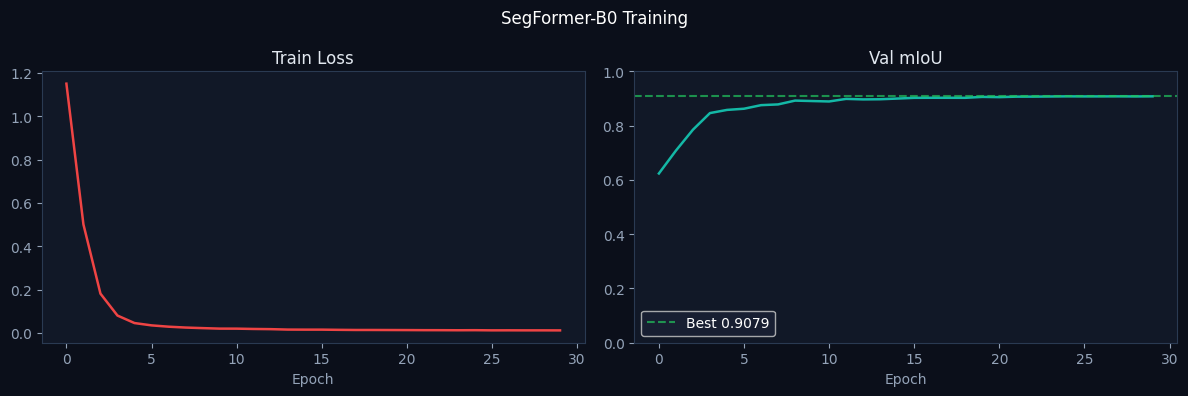

Saved → /content/training_curves.png


In [19]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"SegFormer-{MODEL_SIZE} Training", color='white', fontsize=12)
fig.patch.set_facecolor('#0b0f1a')

for ax in (ax1, ax2):
    ax.set_facecolor('#111827')
    ax.tick_params(colors='#94a3b8')
    for spine in ax.spines.values():
        spine.set_color('#2a3a52')

ax1.plot(history['loss'], color='#ef4444', linewidth=1.8)
ax1.set_title('Train Loss', color='#e2e8f0')
ax1.set_xlabel('Epoch', color='#94a3b8')

ax2.plot(history['miou'], color='#14b8a6', linewidth=1.8)
ax2.axhline(best_miou, linestyle='--', color='#22c55e', alpha=0.7,
            label=f'Best {best_miou:.4f}')
ax2.set_ylim(0, 1)
ax2.set_title('Val mIoU', color='#e2e8f0')
ax2.set_xlabel('Epoch', color='#94a3b8')
ax2.legend(facecolor='#1a2236', labelcolor='white')

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()
print("Saved → /content/training_curves.png")

/tmp/ipykernel_24139/2014729597.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast():


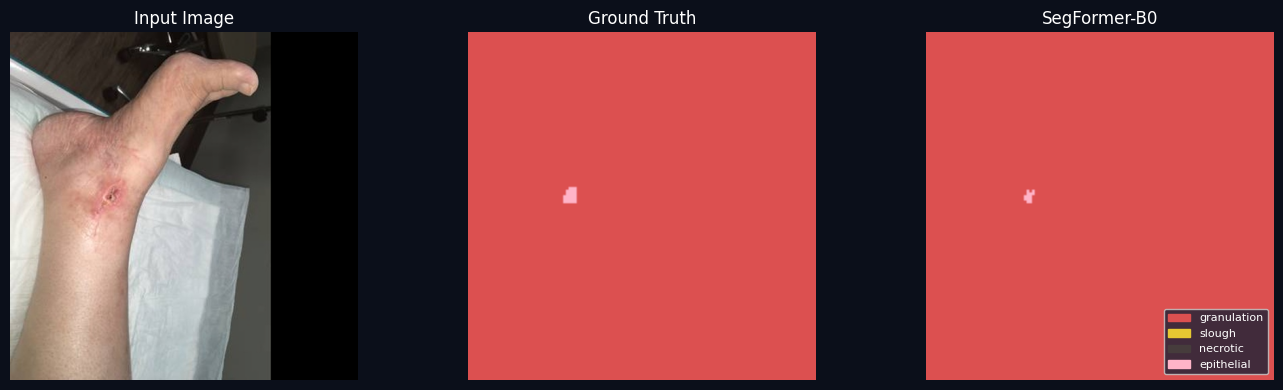

In [20]:
import matplotlib.pyplot as plt
import numpy as np, torch, torch.nn.functional as F
from torch.cuda.amp import autocast

COLORS = {0: [220,80,80], 1: [230,200,50], 2: [70,60,60], 3: [255,180,200]}

def colorise(seg):
    rgb = np.zeros((*seg.shape, 3), dtype=np.uint8)
    for c, col in COLORS.items():
        rgb[seg == c] = col
    return rgb

model.eval()
sample = WoundDataset('val')[0]
pv     = sample['pixel_values'].unsqueeze(0).to(device)
lbl    = sample['labels'].numpy()

with torch.no_grad(), autocast():
    logits = model(pixel_values=pv).logits
up   = F.interpolate(logits, size=lbl.shape, mode='bilinear', align_corners=False)
pred = up.argmax(1).squeeze(0).cpu().numpy()

img = sample['pixel_values'].permute(1, 2, 0).numpy()
img = (img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])).clip(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor('#0b0f1a')
for ax, im, title in zip(axes, [img, colorise(lbl), colorise(pred)],
                         ['Input Image', 'Ground Truth', f'SegFormer-{MODEL_SIZE}']):
    ax.imshow(im); ax.set_title(title, color='white'); ax.axis('off')

handles = [plt.Rectangle((0,0),1,1, color=[c/255 for c in v]) for v in COLORS.values()]
axes[2].legend(handles, list(ID2LABEL.values()), loc='lower right',
               facecolor='#1a2236', labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig('/content/pred_sample.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()

In [21]:
import shutil, os
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

model = SegformerForSemanticSegmentation.from_pretrained(OUTPUT_DIR)
print(f"Loaded best model (mIoU={best_miou:.4f})")

processor = SegformerImageProcessor.from_pretrained(HF_ID, do_reduce_labels=False)
processor.save_pretrained(OUTPUT_DIR)

shutil.make_archive('/content/segformer_wound', 'zip', OUTPUT_DIR)
size_mb = os.path.getsize('/content/segformer_wound.zip') / 1024 / 1024
print(f"Zipped ({size_mb:.1f} MB) → /content/segformer_wound.zip")

from google.colab import files
files.download('/content/segformer_wound.zip')

print("""
✅ Download started!
   1. Unzip segformer_wound.zip
   2. Move to: backend/models/segformer_wound/
   3. Set MOCK_MODE=false in backend/.env
   4. Restart uvicorn
""")

Loaded best model (mIoU=0.9079)


preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/utils/deprecation.py:165: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type'
  return func(*args, **kwargs)


Zipped (13.2 MB) → /content/segformer_wound.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download started!
   1. Unzip segformer_wound.zip
   2. Move to: backend/models/segformer_wound/
   3. Set MOCK_MODE=false in backend/.env
   4. Restart uvicorn



In [22]:
!pwd
!ls

/content
drive		 sample_data	      training_curves.png
fuseg.zip	 segformer_wound      wound_data
pred_sample.png  segformer_wound.zip  wound-segmentation-master


In [23]:
!mv /content/segformer_wound.zip /content/drive/MyDrive/


In [24]:
!ls /content/drive/MyDrive/

'22ESC142 Module 5.gdoc'
 240311147026_ApplicationForm.pdf
 3ba28adc-9969-4976-871e-242b8e4713de.xlsx
 6489aef3bb3ccf0018bc4b17_##_Current_Electricity_13_Class_Notes_Lakshya.gdoc
 assignmenteedited.pdf
 assignment.pdf
 Biology.pdf
'CamScanner 12-22-2022 09.19.40.pdf'
 chemistry.pdf
 Classroom
'Colab Notebooks'
'Flip-Flops and Registers (1).gslides'
'Flip-Flops and Registers.gslides'
 Geography.pdf
 HarshaTCaecassignmet.pdf
 HarshatcAEC.pdf
 HarshaTCaec.pdf
'Harsha T C_CodeCrypt 2.0.pdf'
'History Civics.pdf'
 Kannada.pdf
'Physical Education.pdf'
 physics.pdf
'Pipeline Hazards.gslides'
'Pipeline Hazards Technical.gslides'
 quizze.pdf
 segformer_wound.zip
'skx-astx-qsc – 28 Feb 2024.pdf'
'Untitled folder'
'Welcome Function Invitation - 2024.pdf'
 wscan_training
'xaj-iffy-miz – 5 Feb 2024.pdf'
